In [17]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("/home/fyp_ids_e20/dataset/02-14-2018.csv")

print(df['Label'].value_counts())

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


In [19]:
print(df.columns.tolist())

['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd By

In [20]:
benign = df[df['Label'] == 'Benign']
dos = df[df['Label'] == 'FTP-BruteForce']
ddos = df[df['Label'] == 'SSH-BruteForce']

In [21]:
# non_features = ['Flow Duration', 'Timestamp', 'Dst Port', 'Protocol', 'Label']

In [22]:
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

print(len(network_features))

22


In [23]:
# Keep only selected features + Label
df_selected = df[network_features + ["Label"]].copy()

# Replace inf values
df_selected.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values using median (safe for IDS)
df_selected.fillna(df_selected.median(numeric_only=True), inplace=True)

,Dst Port,Protocol,Flow Duration,Flow IAT Mean,Flow IAT Max,Flow IAT Min,Fwd IAT Max,Fwd IAT Min,Fwd IAT Tot,Flow Pkts/s,...,Subflow Fwd Pkts,Fwd Header Len,Bwd Header Len,Init Fwd Win Byts,Init Bwd Win Byts,PSH Flag Cnt,RST Flag Cnt,ACK Flag Cnt,ECE Flag Cnt,Label
0,0,0,112641719,5.632086e+07,56320958,56320761,56320958,56320761,112641719,0.026633,...,3,0,0,-1,-1,0,0,0,0,Benign
1,0,0,112641466,5.632073e+07,56320814,56320652,56320814,56320652,112641466,0.026633,...,3,0,0,-1,-1,0,0,0,0,Benign
2,0,0,112638623,5.631931e+07,56319525,56319098,56319525,56319098,112638623,0.026634,...,3,0,0,-1,-1,0,0,0,0,Benign
3,22,6,6453966,2.689152e+05,673900,22,673900,229740,6453966,3.873587,...,15,488,328,65535,233,1,0,0,0,Benign
4,22,6,8804066,3.668361e+05,1928102,21,1928102,246924,8804066,2.839597,...,14,456,360,5808,233,1,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,80,6,10156986,1.128554e+06,9902474,17,123760,486,254512,0.984544,...,5,112,104,8192,31111,1,0,0,0,Benign
1048571,80,6,117,1.170000e+02,117,117,117,117,117,17094.017094,...,2,40,0,64240,-1,0,0,1,0,Benign
1048572,80,6,5095331,1.698444e+06,5060628,30,5060628,34703,5095331,0.785032,...,3,72,32,8192,29200,1,0,0,0,Benign
1048573,80,6,5235511,1.745170e+06,5139436,40,5139436,96075,5235511,0.764013,...,3,72,32,8192,42780,1,0,0,0,Benign


In [24]:
summary = df_selected.groupby("Label")[network_features].agg(
    ["mean", "std", "min", "max"]
)

summary.to_csv("feature_summary_file1.csv")
summary.head()

Dst Port                           Protocol                \
                       mean           std min    max      mean       std min   
Label                                                                          
Benign          7646.404876  17507.880544   0  65533  9.310135  5.222056   0   
FTP-BruteForce    21.000000      0.000000  21     21  6.000000  0.000000   6   
SSH-Bruteforce    21.999840      0.012645  21     22  6.000000  0.000000   6   

                   Flow Duration                ... RST Flag Cnt      \
               max          mean           std  ...          min max   
Label                                           ...                    
Benign          17  9.773471e+06  1.579433e+09  ...            0   1   
FTP-BruteForce   6  3.803196e+00  5.831353e+00  ...            0   0   
SSH-Bruteforce   6  1.833497e+05  1.846828e+05  ...            0   0   

               ACK Flag Cnt                   ECE Flag Cnt                   
                       mean       std min max         mean      std min max  
Label                                                                        
Benign             0.273397  0.445703   0   1     0.062201  0.24152   0   1  
FTP-BruteForce     0.000000  0.000000   0   0     0.000000  0.00000   0   0  
SSH-Bruteforce     0.499715  0.500001   0   1     0.000000  0.00000   0   0  

[3 rows x 88 columns]

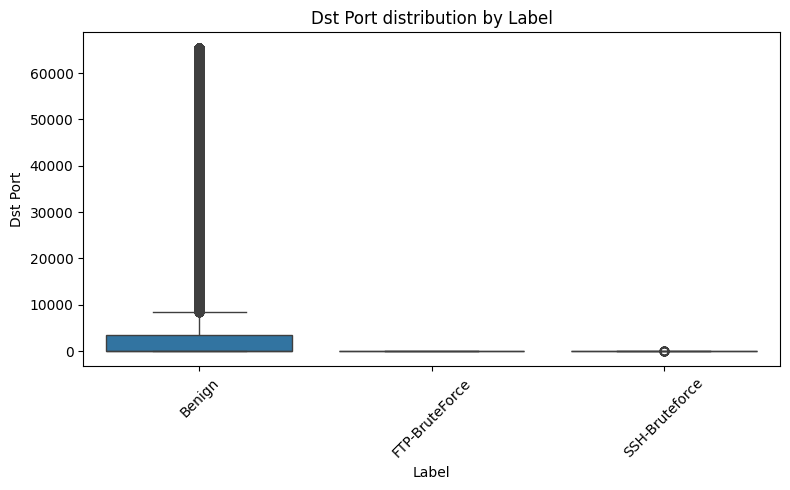

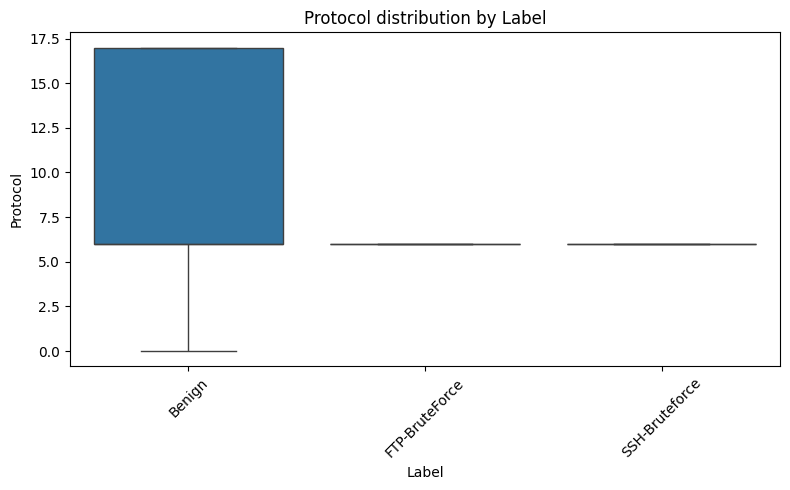

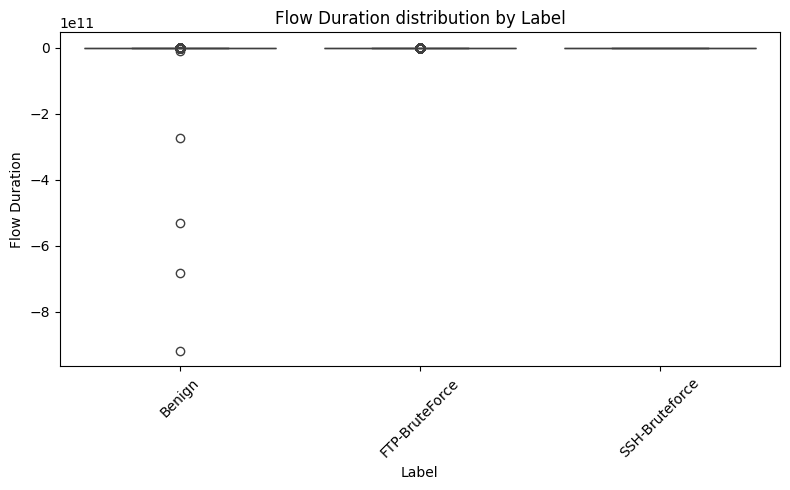

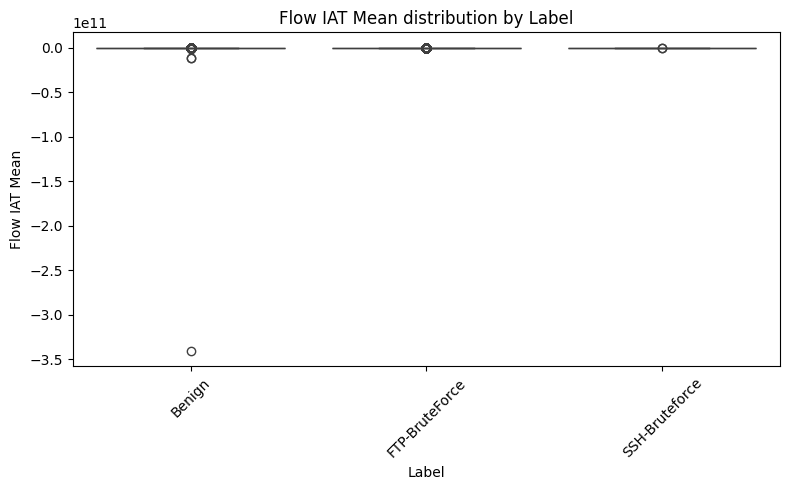

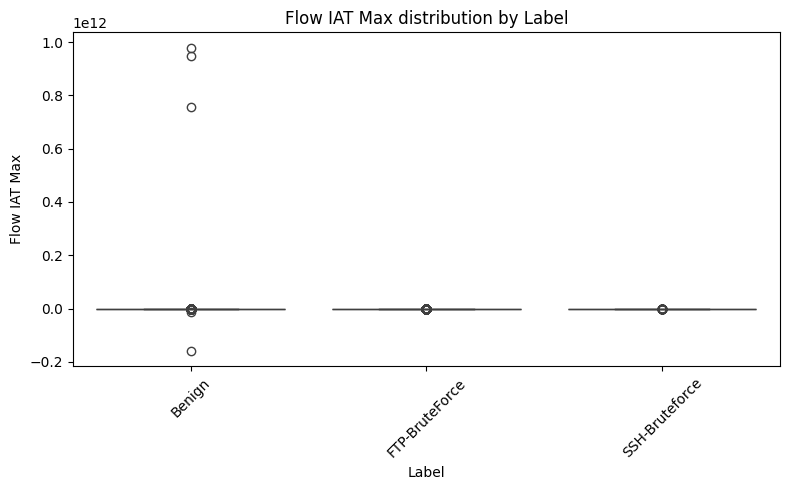

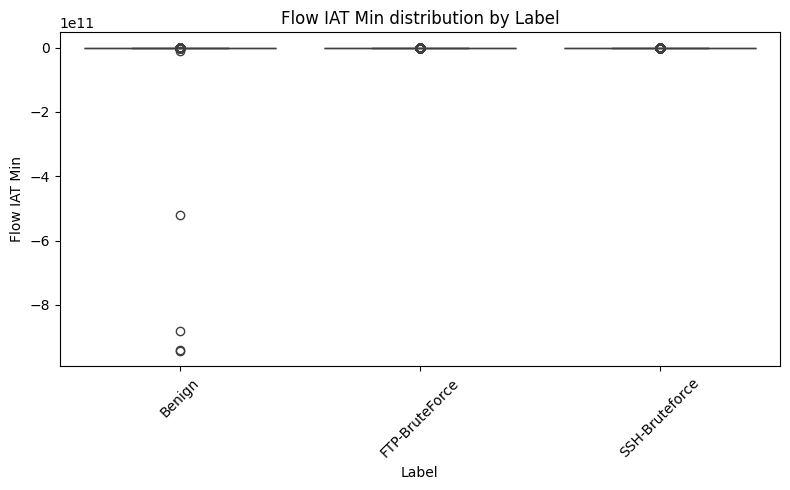

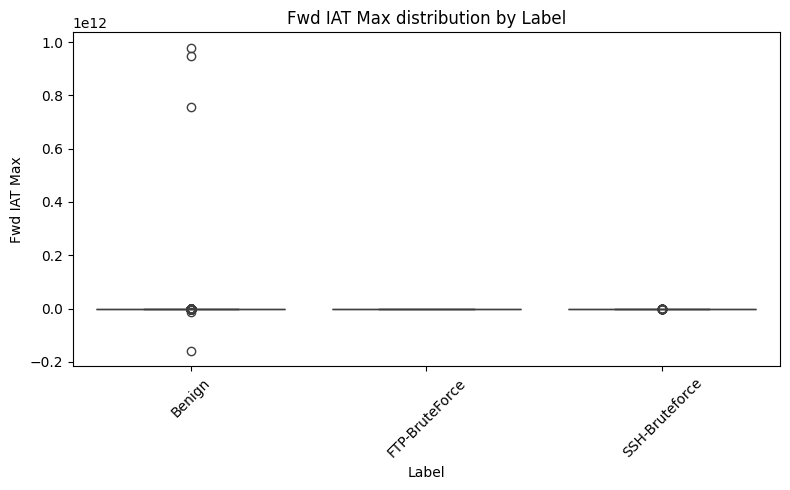

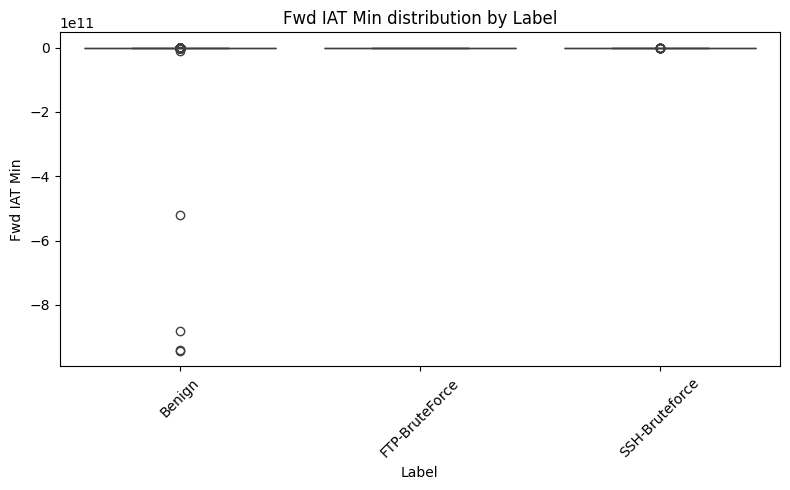

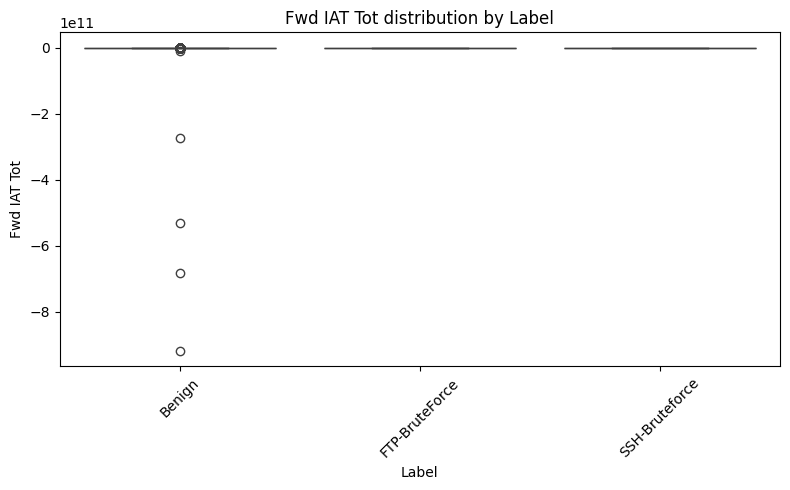

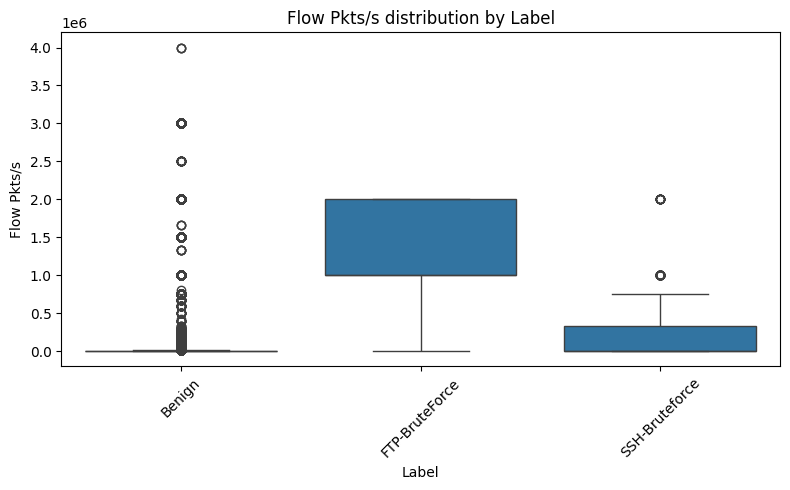

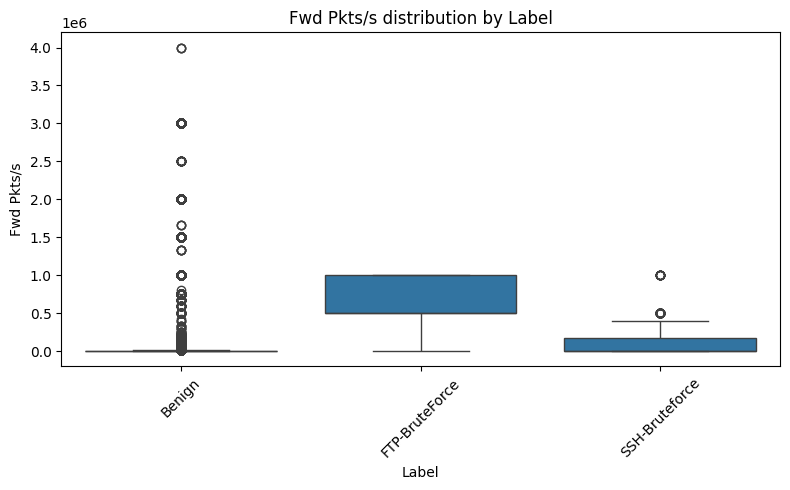

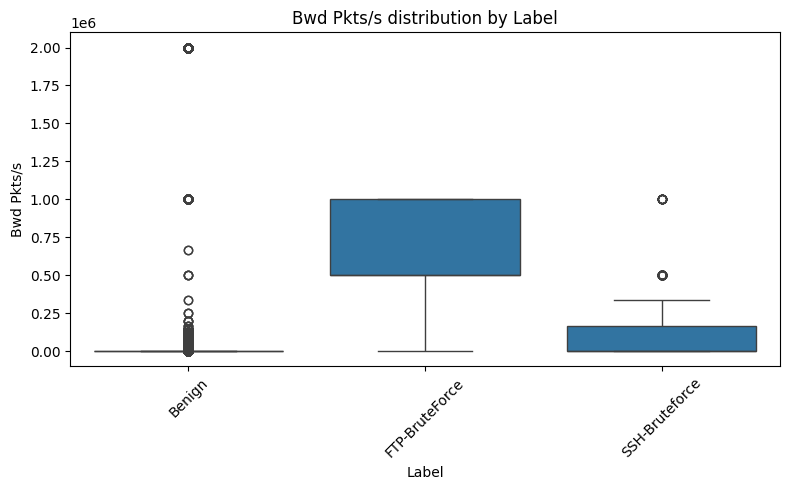

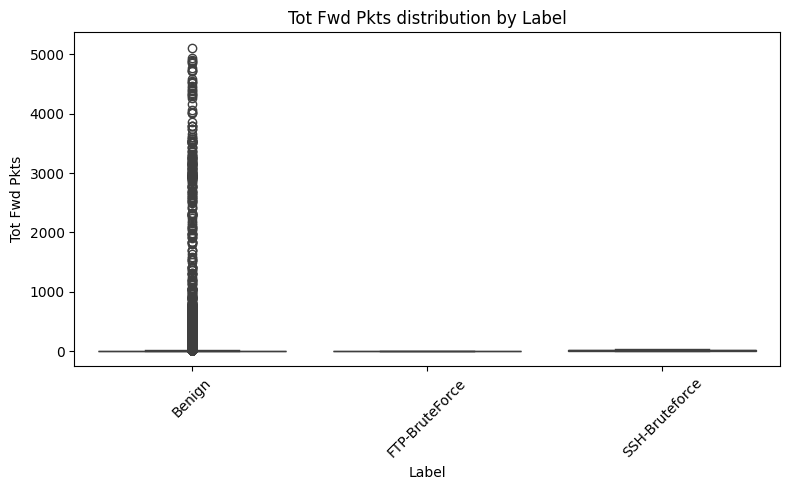

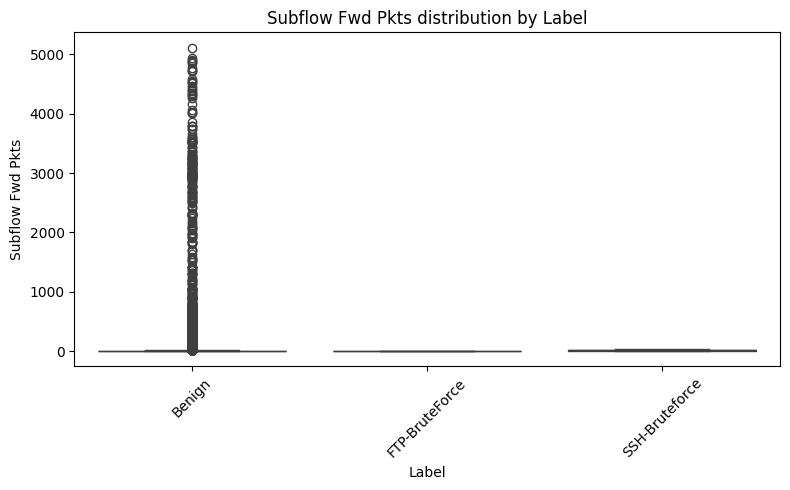

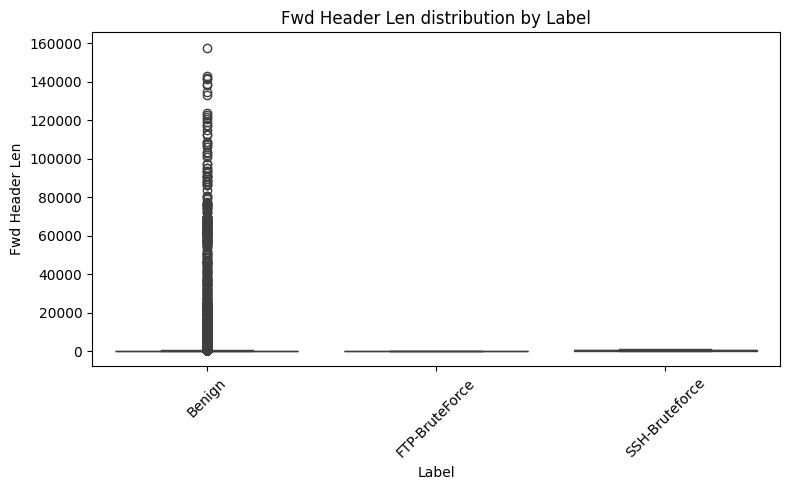

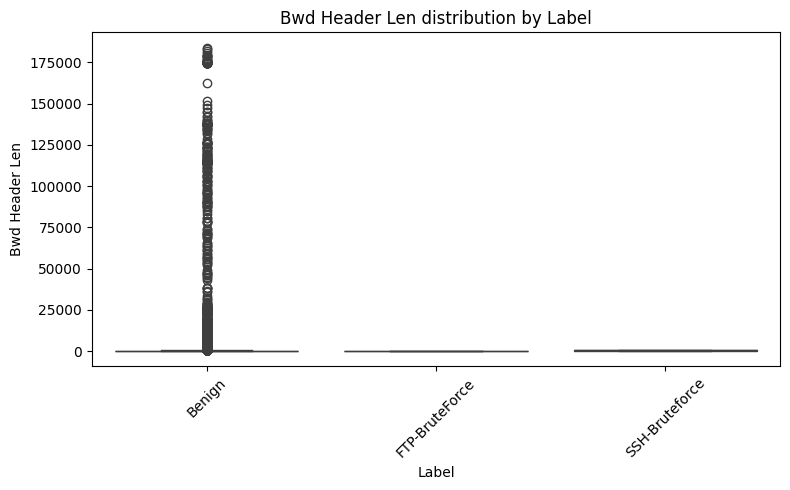

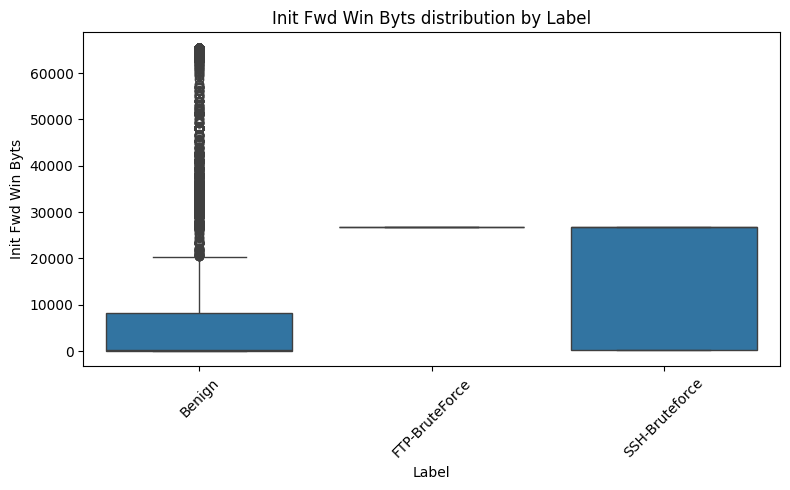

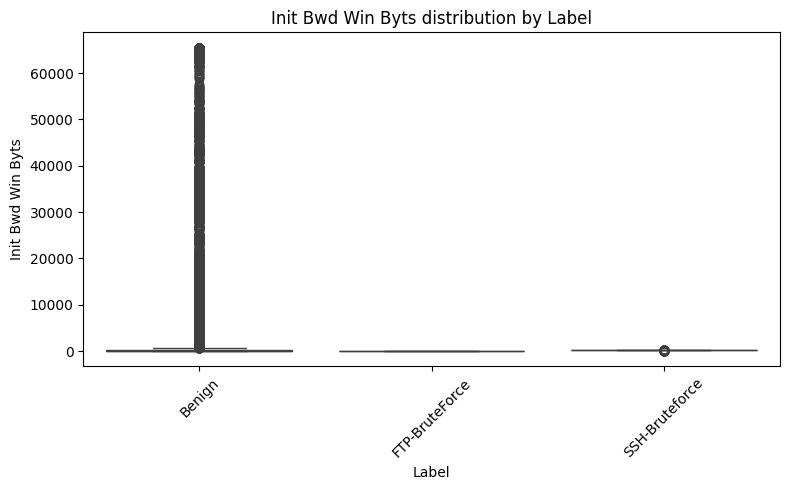

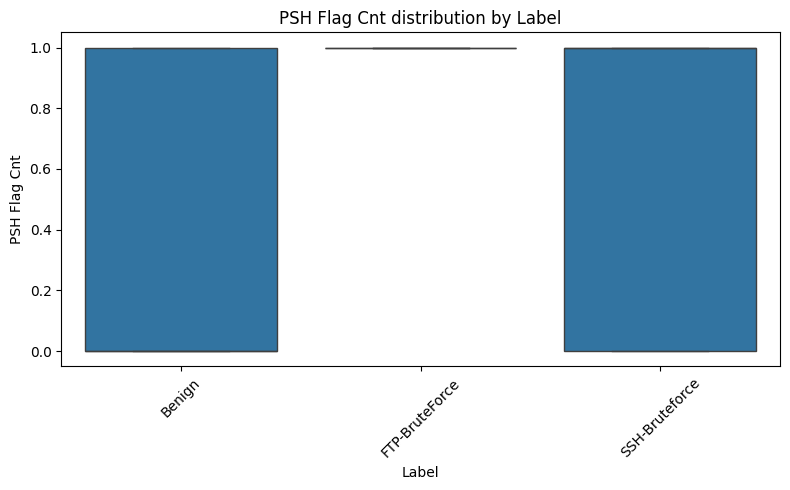

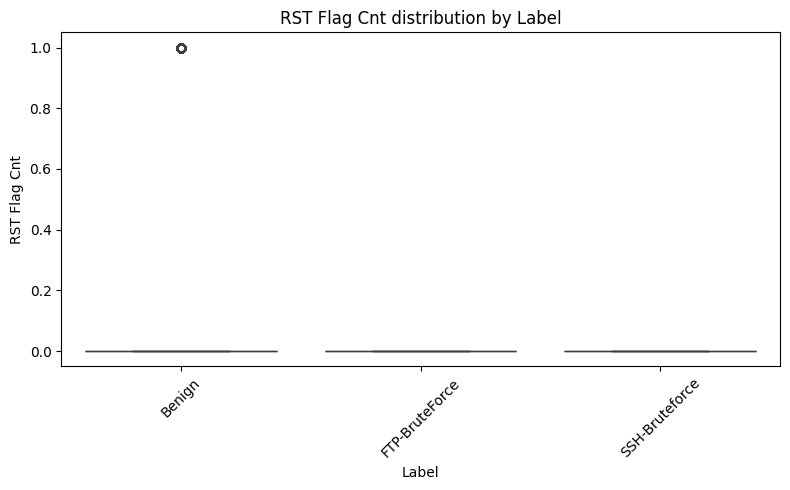

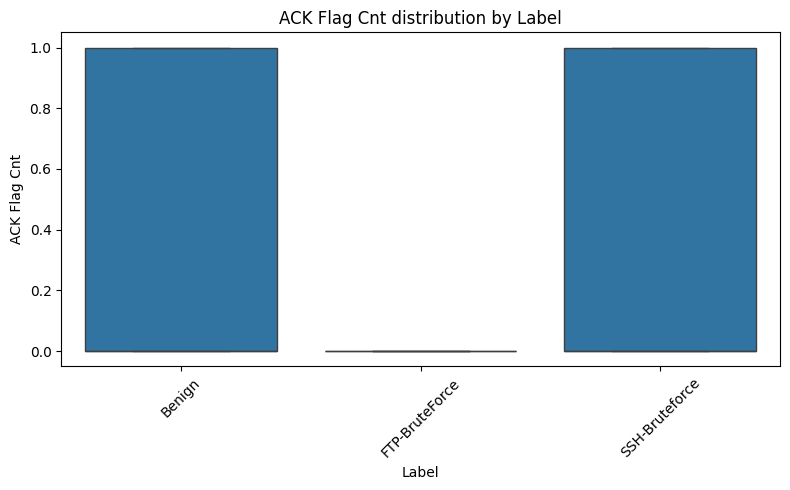

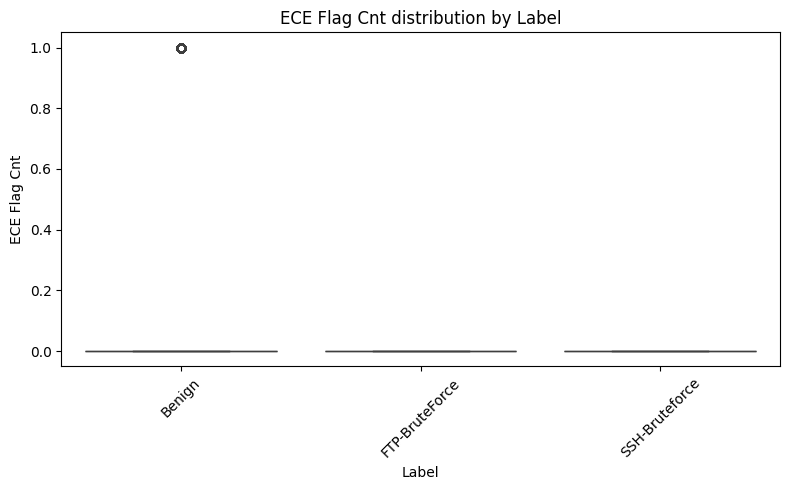

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in network_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Label", y=feature, data=df_selected)
    plt.xticks(rotation=45)
    plt.title(f"{feature} distribution by Label")
    plt.tight_layout()
    plt.show()

In [ ]:
for feature in network_features:
    plt.figure(figsize=(8,5))
    sns.violinplot(x="Label", y=feature, data=df_selected)
    plt.xticks(rotation=45)
    plt.title(f"{feature} variation across traffic types")
    plt.tight_layout()
    plt.show()

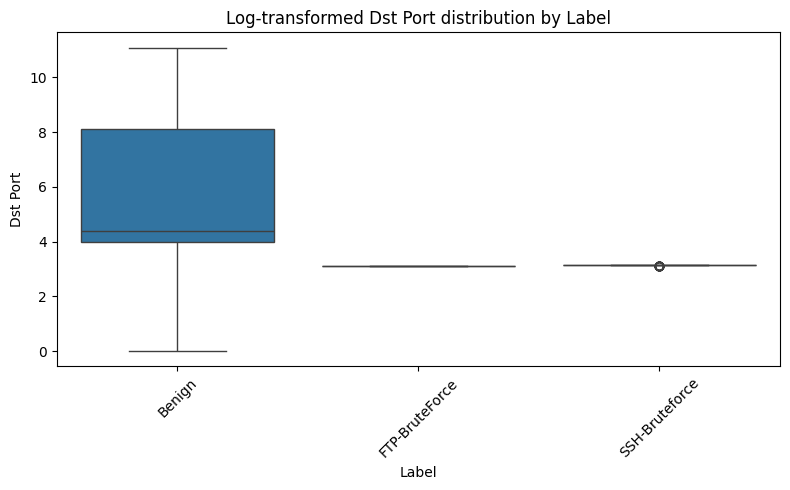

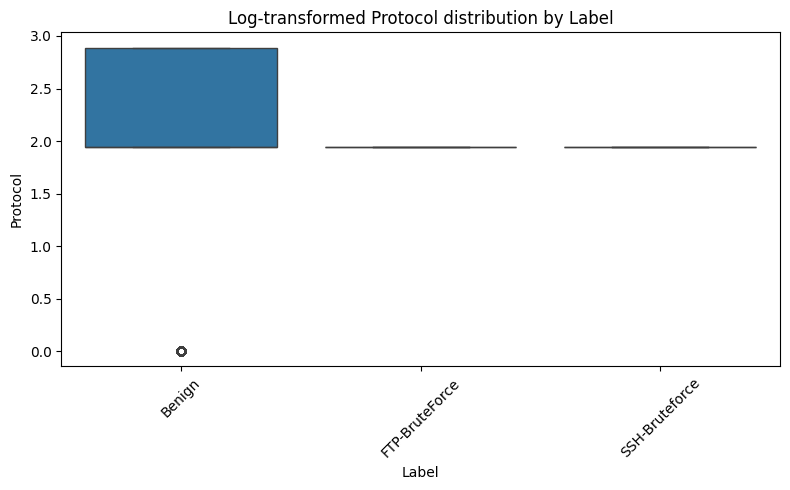

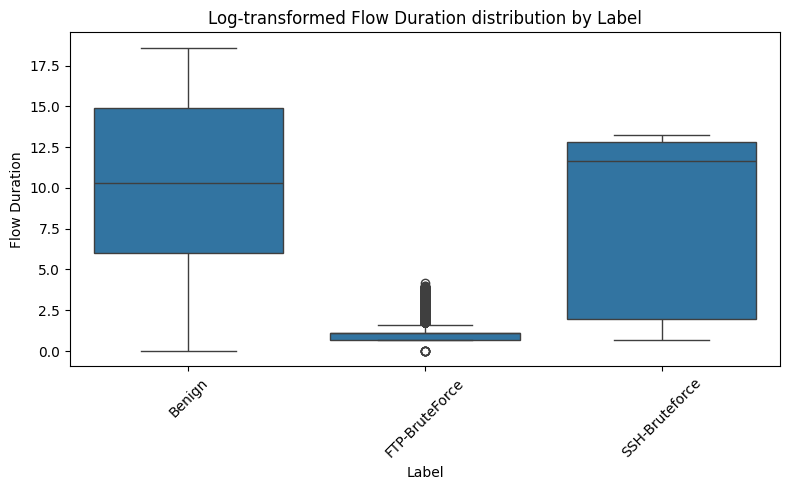

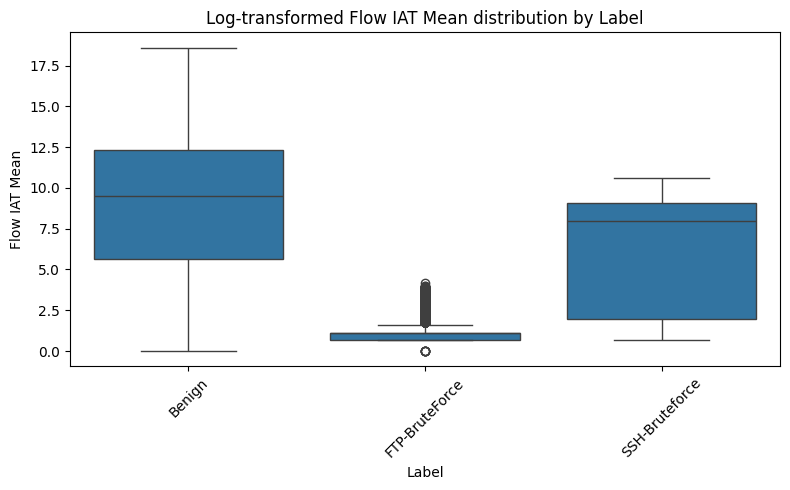

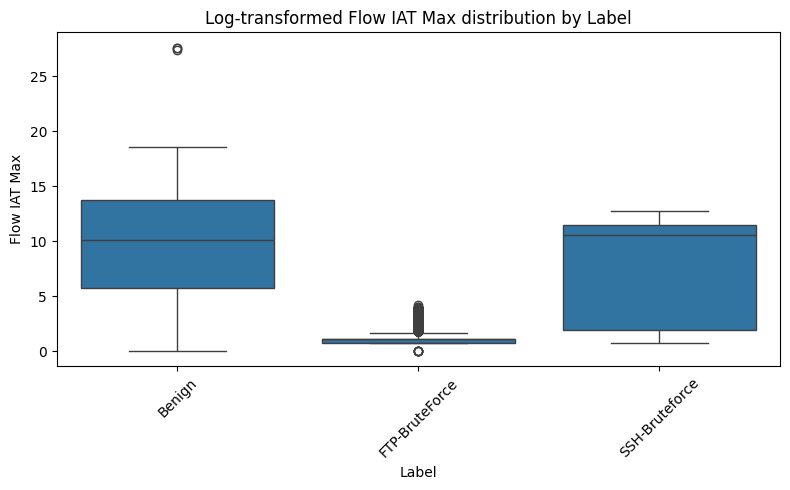

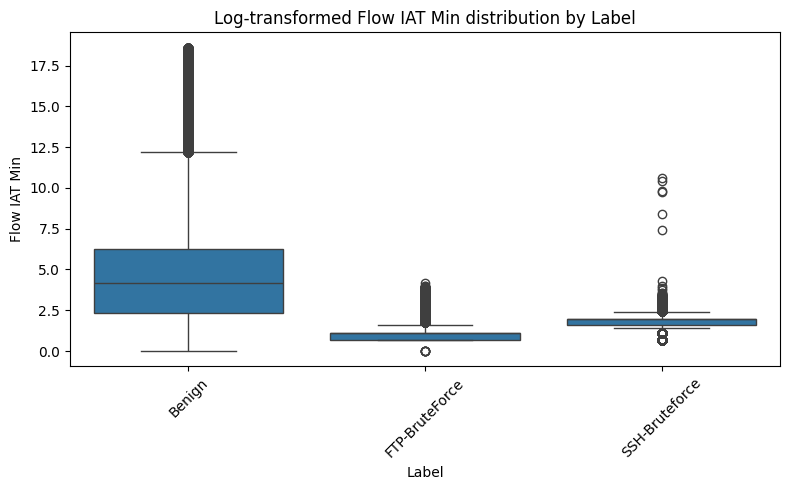

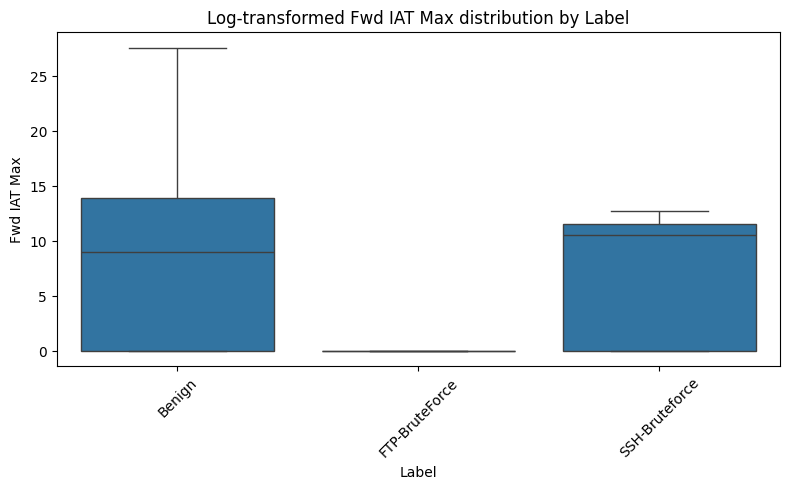

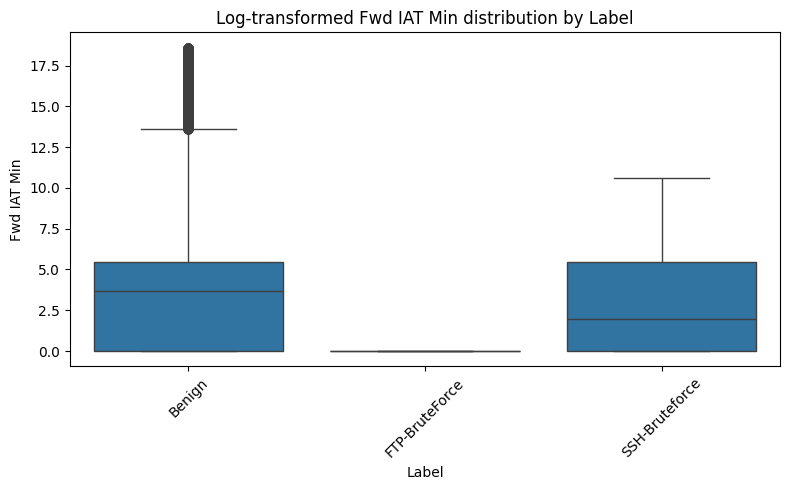

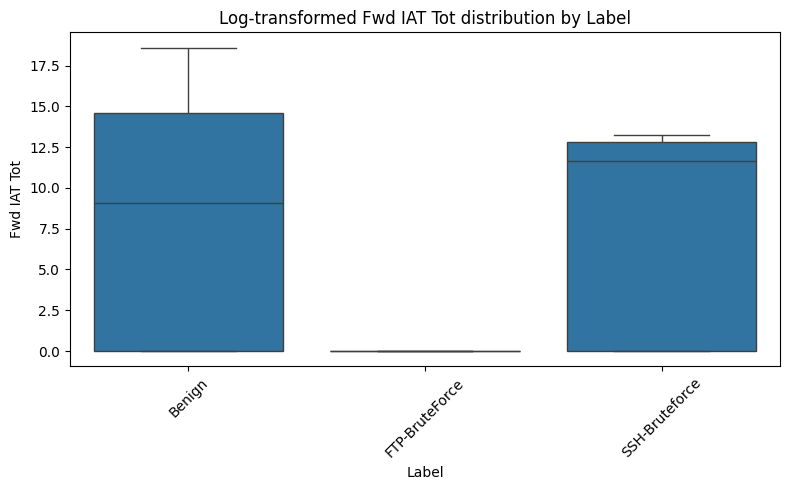

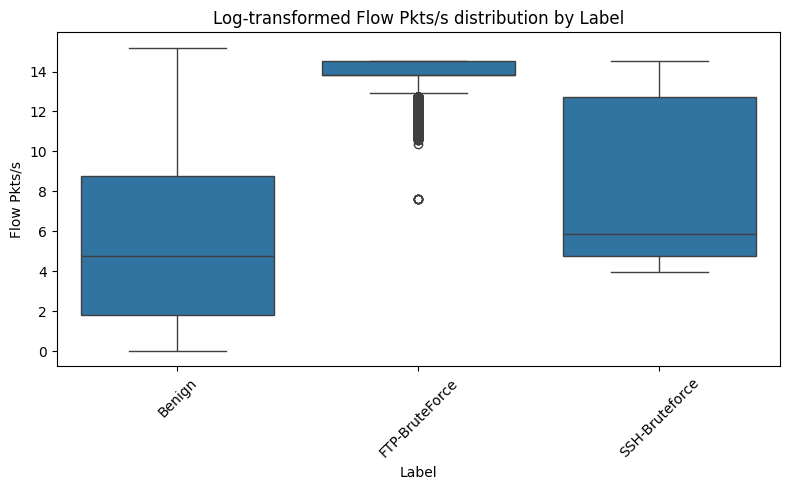

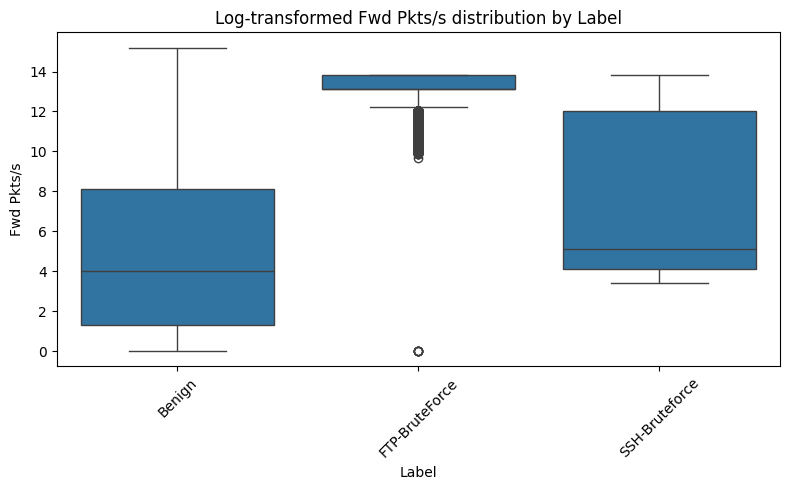

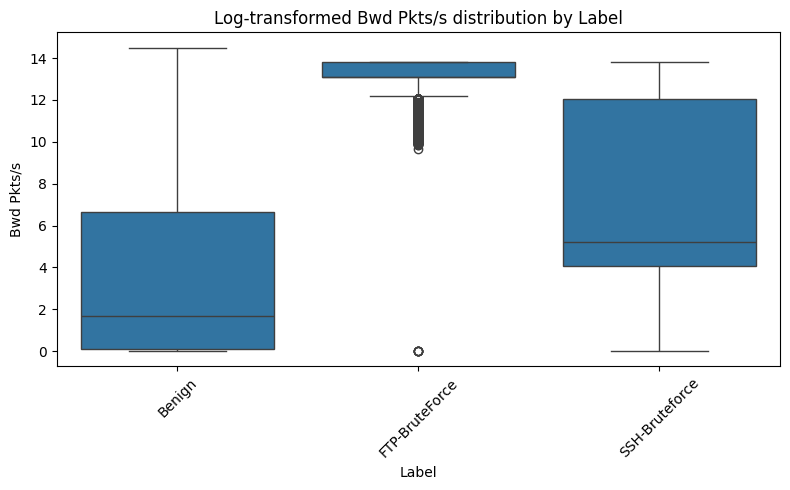

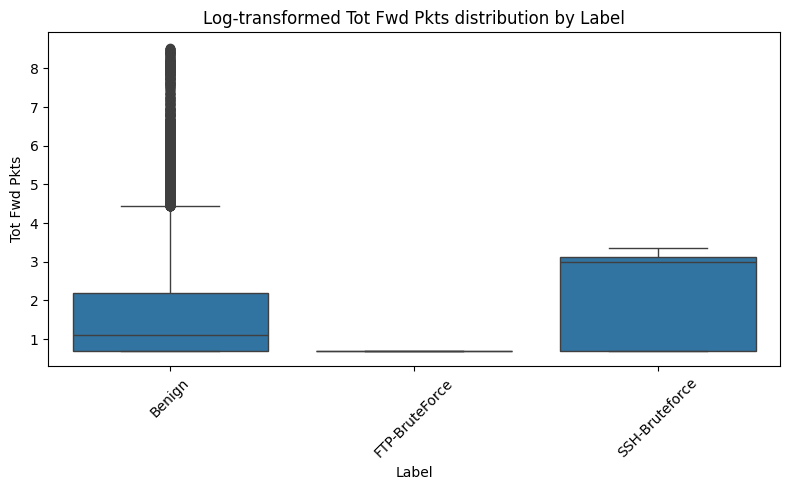

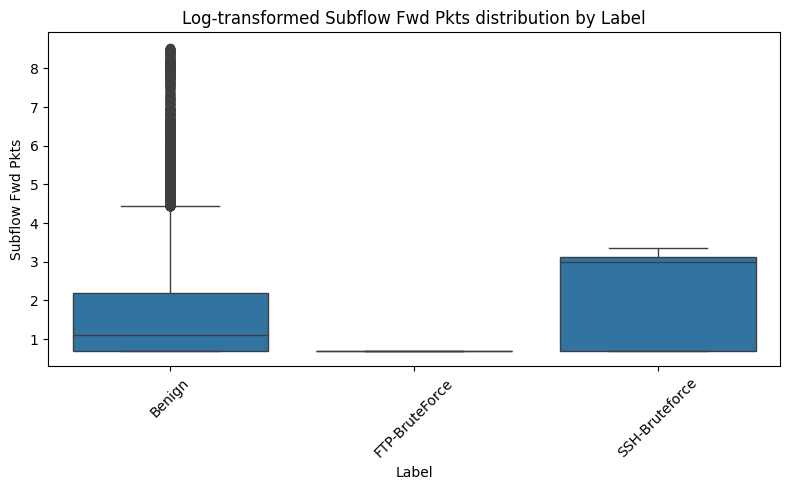

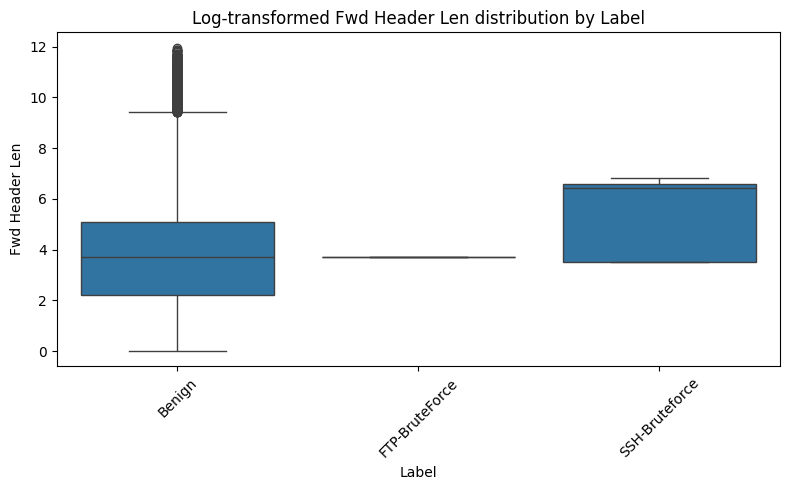

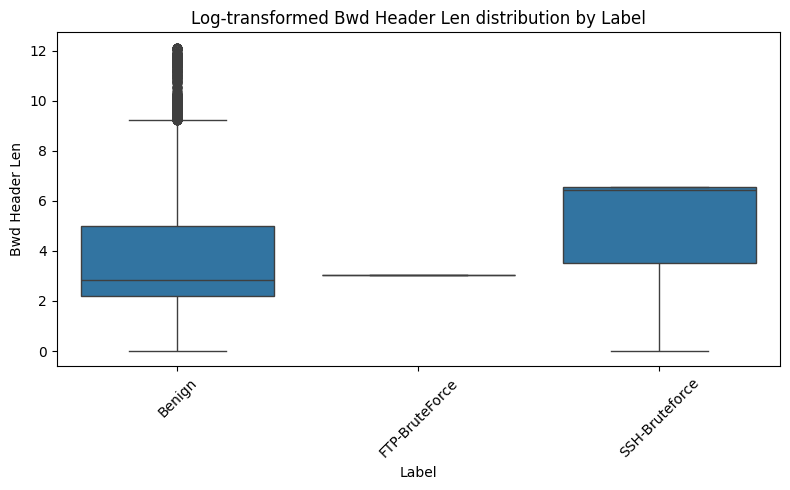

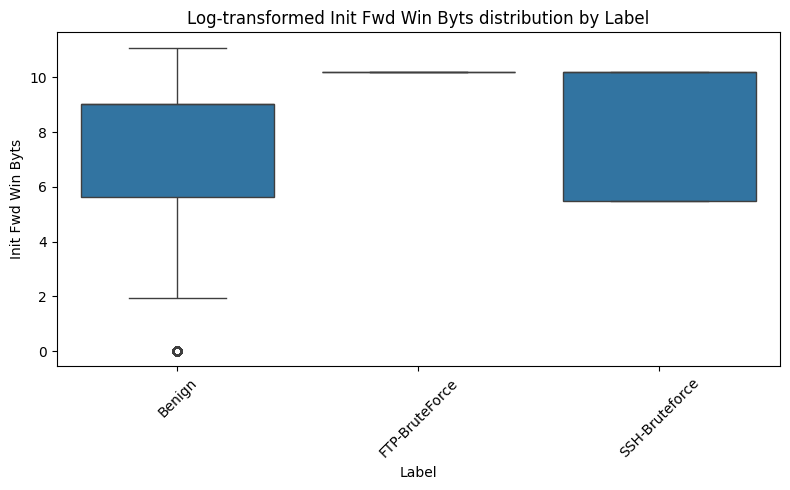

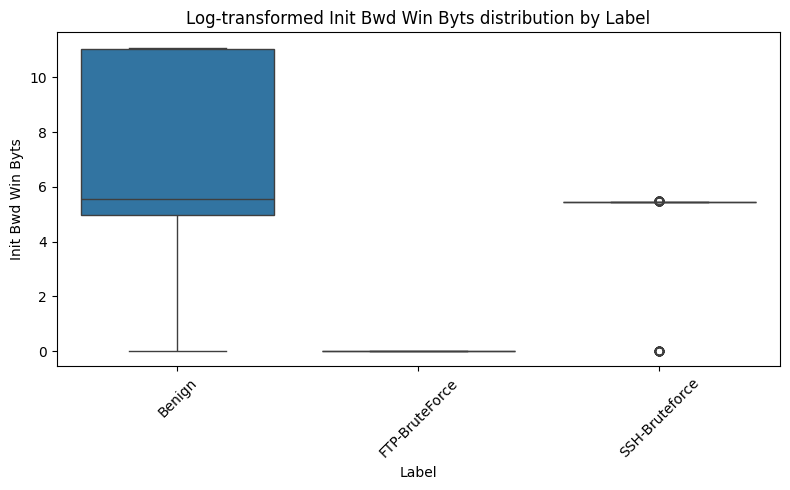

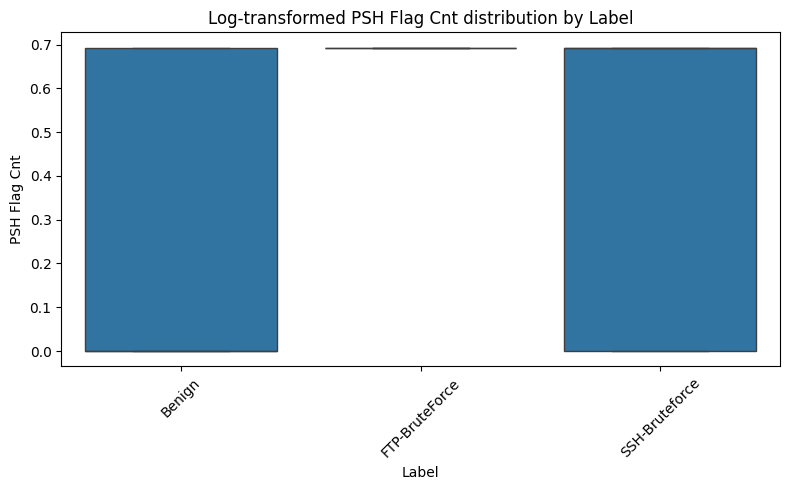

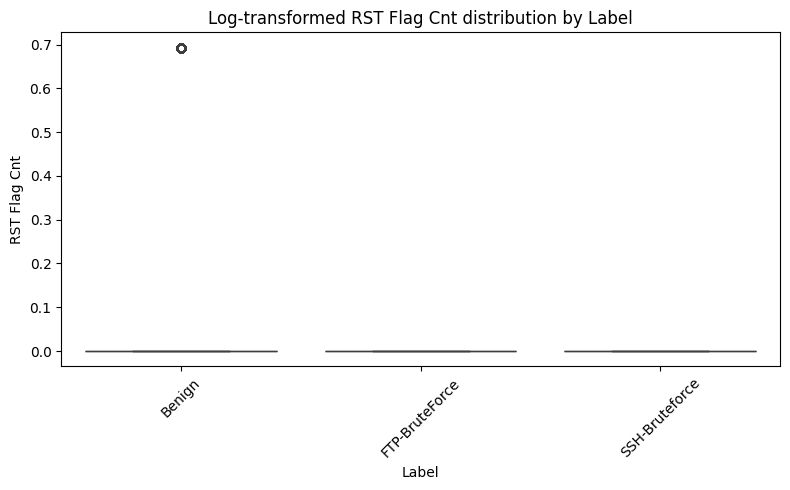

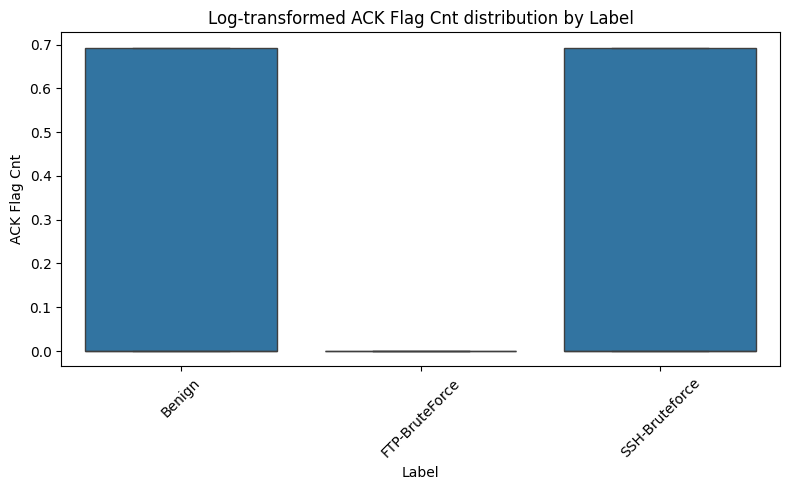

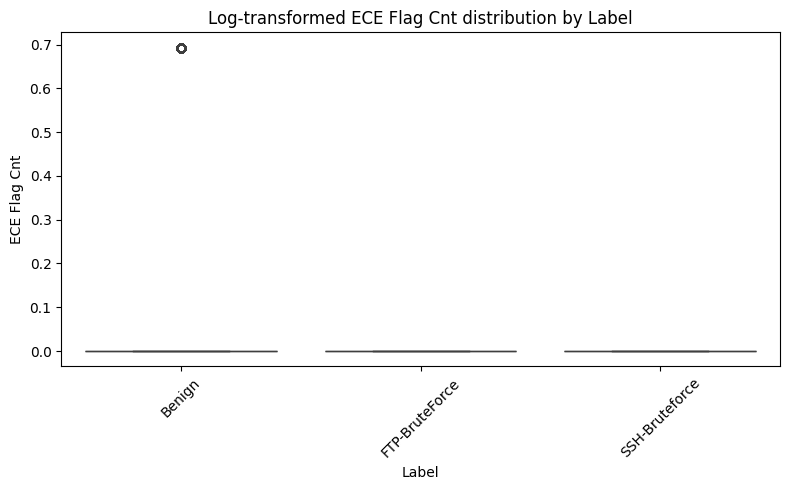

In [30]:
df_selected_log = df_selected.copy()

for col in network_features:
    df_selected_log[col] = np.log1p(df_selected_log[col])

for feature in network_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Label", y=feature, data=df_selected_log)
    plt.xticks(rotation=45)
    plt.title(f"Log-transformed {feature} distribution by Label")
    plt.tight_layout()
    plt.show()